# XGBoost Model

## 📌 Notebook Overview

This notebook implements and evaluates [**XGBoost (Extreme Gradient Boosting) classifiers**](https://xgboost.readthedocs.io/en/release_3.2.0//) to predict multiple clinical outcomes in neuroblastoma using gene expression data from two platforms:

- RNA-Seq  
- Microarray  

The objective is to compare model performance across:
1. Different clinical outcomes  
2. Different transcriptomic platforms  

---

## 🎯 Objectives

- Preprocess gene expression datasets using custom utility functions.
- Train XGBoost models with appropriate handling of class imbalance.
- Evaluate predictive performance using multiple classification metrics.
- Compare RNA-Seq vs Microarray predictive performance.
- Assess model robustness using cross-validation.
- Investigate feature importance and boosted decision patterns.

---

## ⚙️ Methodology

### 1️⃣ Data Loading & Preprocessing
- Data is loaded using a custom `get_data()` function.
- Pre-defined train/test splits are used.
- Dimensionality and class distribution checks are performed.

### 2️⃣ Handling Class Imbalance
- Class imbalance is addressed using SMOTE within a pipeline. This ensures improved learning for minority outcome classes.

### 3️⃣ Model Training
- Key hyperparameters include:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`
  - `colsample_bytree`
  - `gamma`

Models are trained separately for each:
- Clinical outcome
- Transcriptomic platform

### 4️⃣ Model Evaluation

Models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Stratified K-Fold cross-validation is used to assess generalisation performance and detect potential overfitting.

---

## 📊 Visualisations

The notebook generates:

- ROC curve comparisons (RNA-Seq vs Microarray)
- Grouped bar charts comparing performance metrics across:
  - Outcomes
  - Platforms
- Feature importance plots

---

## 🔎 Key Comparisons

This notebook enables investigation of:

- Does XGBoost outperform Random Forest and Logistic Regression?
- Which transcriptomic platform provides stronger predictive signal?
- Which clinical outcome is most predictable?
- Do boosted ensembles capture additional complex structure in the data?

---

## 📁 Structure of Notebook

1. Import modules  
2. Trial model on "Death from Disease"  
3. Tree visualisation
4. Analyse feature importance  
5. Train models on all outcomes (RNA-Seq & Microarray)  
6. Plot ROC curves  
7. Plot performance comparisons  

---

This notebook introduces gradient boosting to the predictive framework, allowing deeper modeling of complex gene expression patterns and improved comparative analysis across transcriptomic platforms.

## Import modules

In [1]:
!pip install -q scanpy anndata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 92.7 MB/s eta 0:00:00


In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import sys
sys.path.append('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/')

# Data handling
import pandas as pd
import numpy as np
import scanpy as sc

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
import pydot
import graphviz
from IPython.display import Image

# Custom function
from utils import get_data

## Trial on Death from Disease outcome

In [3]:
X_train, X_test, y_train, y_test = get_data('rnaseq', 'death_from_disease')

  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}


In [4]:
X_train

,A1BG,A1CF,A2M,AACSP1,AADAC,ABCA12,ABCA8,ABCB11,ABCB4,ABCC2,...,ZFP36,ZG16,ZIC1,ZIC2,ZIC3,ZIC5,ZNF385B,ZNF664,ZNF664-FAM101A,ZNFX1-AS1
NB297,8.397936,3.338918,9.026266,3.184915,5.341897,0.116456,2.558980,2.221596,3.756255,3.801738,...,5.114138,1.947737,0.000000,0.0,0.000000,0.000000,2.231110,5.042469,0.224712,5.310424
NB209,1.806662,0.005419,6.004879,3.558476,0.034047,0.192767,0.421682,0.123370,1.039181,0.135225,...,6.910241,0.000000,0.009733,0.0,0.000000,0.000000,0.000000,5.236451,1.182673,6.001795
NB043,1.306875,0.030836,6.074199,2.340400,0.000000,0.203101,0.147723,0.019613,0.419086,0.278613,...,4.364411,0.000000,0.000000,0.0,0.000000,0.000000,0.667125,5.105255,1.014805,5.214964
NB493,1.649027,0.005746,5.223052,4.457667,0.000000,3.048855,0.018776,0.000000,0.731000,0.246387,...,4.438326,0.000000,0.000000,0.0,0.000000,0.000000,0.083393,5.248565,0.948311,5.001298
NB103,1.701775,0.025598,5.979589,1.520819,0.059815,0.799789,0.280371,0.018995,0.629763,0.070420,...,5.070879,0.000000,0.000000,0.0,0.206363,0.000000,0.504105,4.637755,0.801708,4.429770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB389,2.540464,0.006285,4.539655,0.441973,0.000000,1.428925,0.060731,0.000000,0.369153,0.459315,...,2.900413,0.000000,0.000000,0.0,0.000000,0.088021,0.159851,5.269478,1.125757,5.965348
NB427,2.797397,0.894051,6.401320,2.674619,2.436474,0.144003,0.928639,0.066745,0.863651,0.872535,...,4.227048,0.037998,0.000000,0.0,0.000000,0.000000,1.098103,5.208587,0.512682,5.467563
NB077,1.382025,0.000000,6.033088,4.656044,0.030661,0.044815,1.913841,0.074774,0.450556,0.271409,...,5.060986,0.000000,0.497026,0.0,0.000000,0.000000,0.017978,5.241833,0.461900,5.045679
NB475,2.547615,0.024264,3.913445,1.907379,0.000000,2.897200,0.096953,0.000000,0.288843,0.099133,...,2.540508,0.000000,0.000000,0.0,0.000000,0.000000,3.022725,4.718942,0.213342,7.510614


In [5]:
y_train

,0
NB297,0
NB209,0
NB043,0
NB493,0
NB103,0
...,...
NB389,0
NB427,0
NB077,0
NB475,1


### Model training

In [6]:
# Calculate scale_pos_weight to handle class imbalance (replaces class_weight='balanced')
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Train & fit model
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,  # handles imbalance natively
        random_state=42,
        eval_metric='logloss',              # suppresses warnings
        verbosity=0                         # suppresses output
    ))
])

pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Performance metrics
print("=" * 50)
print("XGBOOST - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

XGBOOST - PERFORMANCE METRICS

Accuracy:  0.8163
Precision: 0.5294
Recall:    0.9000
F1-Score:  0.6667
ROC-AUC:   0.8487

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.97      0.79      0.87        39
    Died (1)       0.53      0.90      0.67        10

    accuracy                           0.82        49
   macro avg       0.75      0.85      0.77        49
weighted avg       0.88      0.82      0.83        49



### Interpretation

**ROC-AUC of 0.849** is slightly below both Logistic Regression (0.877) and Random
Forest (0.851), suggesting gene expression has a largely linear relationship with
mortality that simpler models capture equally well.

The model achieves the **highest recall for deaths across all models** (0.90),
catching 9/10 true deaths, but at the cost of the lowest precision (0.53) —
indicating more false positives than LR or RF. This aggressive sensitivity towards
the minority class is likely driven by `scale_pos_weight` amplifying the death class
signal.


### Tree Visualisation

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


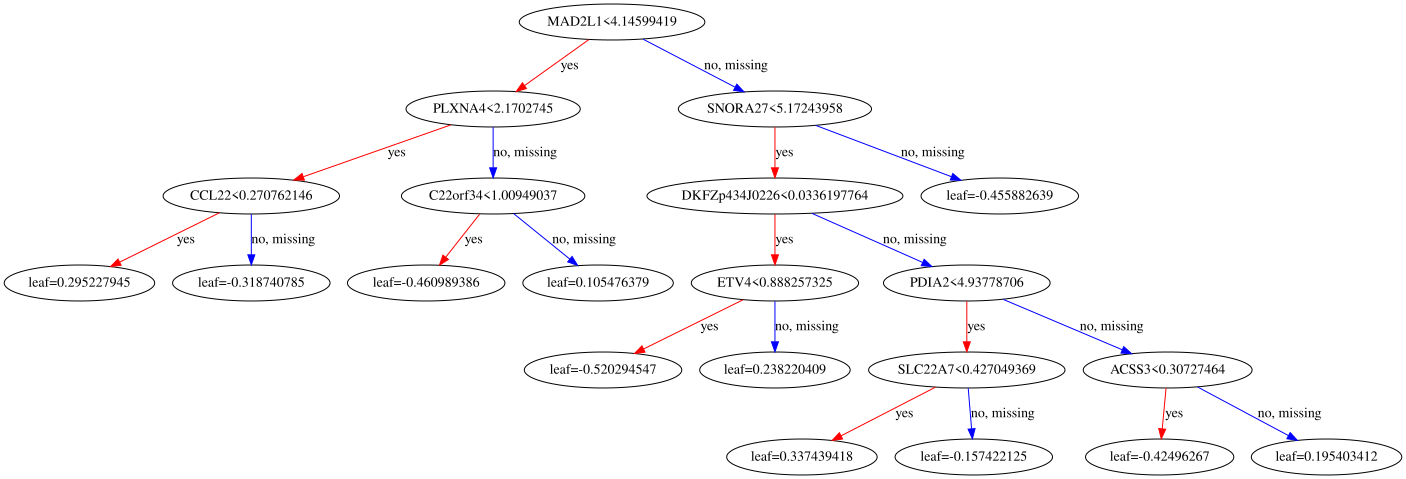

In [7]:
# Extract XGBoost model from pipeline
xgb_classifier = pipeline.named_steps['model']

# Set feature names so tree shows gene names instead of f0, f1, f2...
xgb_classifier.get_booster().feature_names = X_train.columns.tolist()

# Convert to graphviz
tree_dot = xgb.to_graphviz(xgb_classifier, num_trees=2)

# Display directly in notebook
display(tree_dot)

### Feature Importance for Death from Disease

<Figure size 1000x800 with 0 Axes>

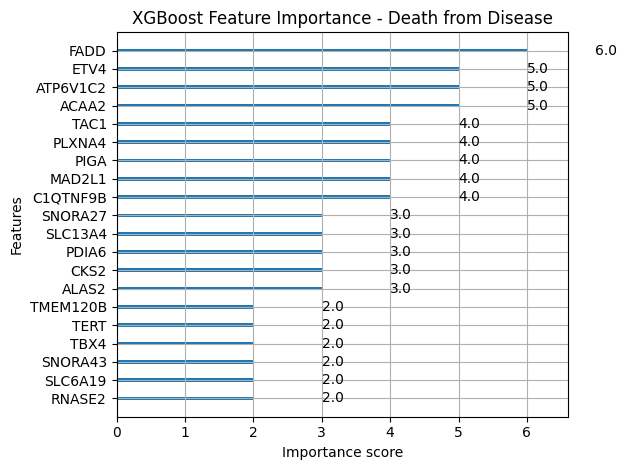

In [8]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_classifier, max_num_features=20)  # top 20 genes
plt.title('XGBoost Feature Importance - Death from Disease')
plt.tight_layout()
plt.show()

### Visualise top 3 features clustering

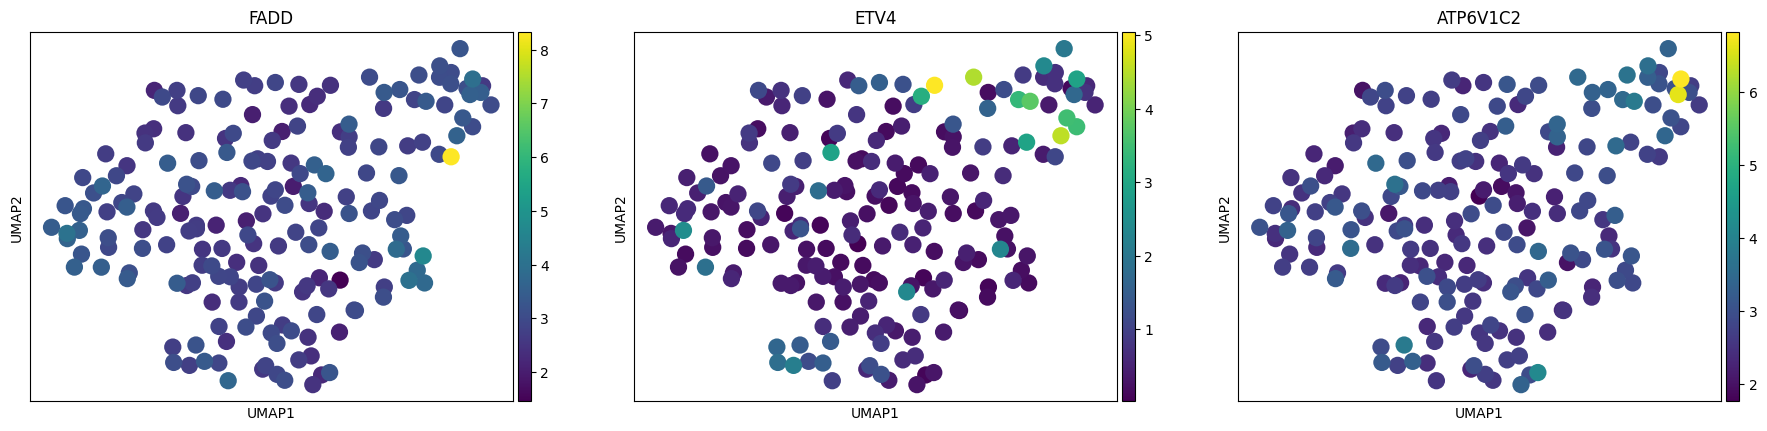

In [9]:
# Create AnnData from X_train
adata = sc.AnnData(
    X=X_train.values,
    obs=pd.DataFrame(index=X_train.index),
    var=pd.DataFrame(index=X_train.columns)
)
adata.obs_names = X_train.index
adata.var_names = X_train.columns

# Add target label
adata.obs['target'] = y_train.values
adata.obs['target'] = adata.obs['target'].astype(str).astype('category')

# Run PCA first
sc.tl.pca(adata, n_comps=20)

# Then compute neighbours using PCA representation
sc.pp.neighbors(adata, n_pcs=20, use_rep='X_pca')

# UMAP
sc.tl.umap(adata, n_components=2)

# Plot top 3 important genes + target
sc.pl.umap(adata, color=["FADD", "ETV4", "ATP6V1C2"])

### Hyperparameter training on Death from Disease

In [10]:
# Calculate scale_pos_weight to handle class imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Define pipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
])

# Define parameters for tuning
param_dist = {
    'model__n_estimators': randint(100, 400),
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.3, 0.7),
    'model__min_child_weight': randint(1, 10),
    'model__gamma': uniform(0, 0.5)
}

# Define randomisedsearchCV
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

# Predict using best model
y_pred = search.predict(X_test)
y_proba = search.predict_proba(X_test)[:, 1]

# Print performance metrics on best model
print("=" * 50)
print("XGBOOST HYPERTUNED - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.9080
Best params: {'model__colsample_bytree': np.float64(0.57660516520127), 'model__gamma': np.float64(0.4633294328968971), 'model__learning_rate': np.float64(0.22818159875692626), 'model__max_depth': 6, 'model__min_child_weight': 9, 'model__n_estimators': 289, 'model__subsample': np.float64(0.7301321323053057)}
XGBOOST HYPERTUNED - PERFORMANCE METRICS

Accuracy:  0.7755
Precision: 0.4737
Recall:    0.9000
F1-Score:  0.6207
ROC-AUC:   0.8744

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.97      0.74      0.84        39
    Died (1)       0.47      0.90      0.62        10

    accuracy                           0.78        49
   macro avg       0.72      0.82      0.73        49
weighted avg       0.87      0.78      0.80        49



## Train models on all outcomes

In [11]:
outcomes = ['death_from_disease', 'high_risk', 'progression', 'inss_stage']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}

print("=" * 70)
print("TRAINING XGBOOST MODELS")
print("=" * 70)

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Detect multiclass
        n_classes = len(y_test.unique())
        is_multiclass = n_classes > 2
        average = 'weighted' if is_multiclass else 'binary'

        # scale_pos_weight only applies to binary classification
        if not is_multiclass:
            scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(
                n_estimators=200,
                max_depth=5,
                scale_pos_weight=scale_pos_weight if not is_multiclass else 1,
                objective='binary:logistic' if not is_multiclass else 'multi:softprob',
                num_class=n_classes if is_multiclass else None,
                random_state=42,
                eval_metric='logloss' if not is_multiclass else 'mlogloss',
                verbosity=0
            ))
        ])

        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0, average=average)
        recall = recall_score(y_test, y_pred, zero_division=0, average=average)
        f1 = f1_score(y_test, y_pred, zero_division=0, average=average)

        if is_multiclass:
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        else:
            y_proba = y_proba[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)

        # Store results
        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        # ROC curve only for binary outcomes
        if not is_multiclass:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data[outcome][platform] = {
                'fpr': fpr,
                'tpr': tpr,
                'auc': roc_auc,
                'y_val': y_test,
                'y_proba': y_proba
            }

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

TRAINING XGBOOST MODELS

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}
  Accuracy:  0.8163
  Precision: 0.5294
  Recall:    0.9000
  F1-Score:  0.6667
  ROC-AUC:   0.8487

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0: 155, 1: 41}
  Test outcome distribution:  {0: 40, 1: 10}
  Accuracy:  0.8600
  Precision: 0.6154
  Recall:    0.8000
  F1-Score:  0.6957
  ROC-AUC:   0.9275

OUTCOME: HIGH RISK

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - High Risk
  Train samples: 194 | Test sa

### Plot ROC Curves

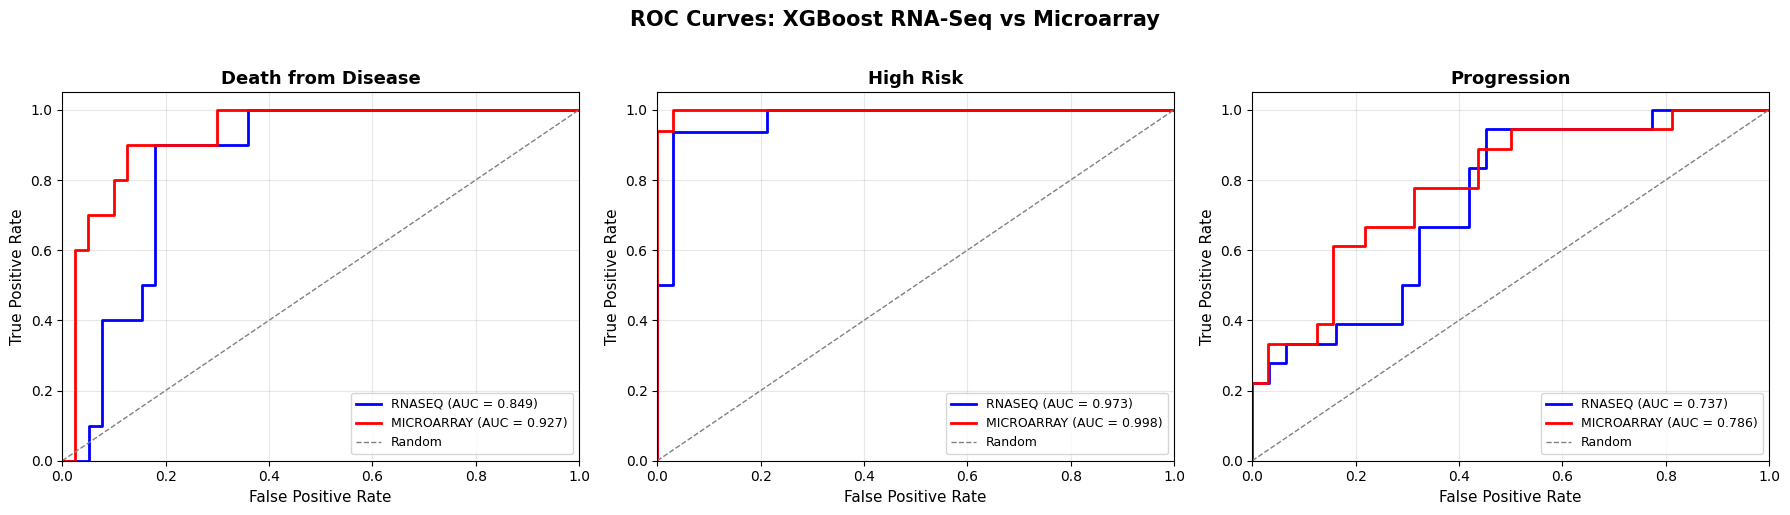

In [12]:
# Only plot binary outcomes — inss_stage is multiclass, no ROC curve
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outcome_titles = {
    'death_from_disease': 'Death from Disease',
    'high_risk': 'High Risk',
    'progression': 'Progression'
}

colors = {
    'rnaseq': 'blue',
    'microarray': 'red'
}

for idx, outcome in enumerate(binary_outcomes):
    ax = axes[idx]

    for platform in platforms:
        # Skip if no ROC data (multiclass outcomes won't have it)
        if platform not in roc_data[outcome]:
            continue

        data = roc_data[outcome][platform]
        ax.plot(data['fpr'], data['tpr'],
                color=colors[platform],
                lw=2,
                label=f"{platform.upper()} (AUC = {data['auc']:.3f})")

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: XGBoost RNA-Seq vs Microarray', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plot Confusion matrix for INSS Stage

  After QC filtering: 243 samples, 20793 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

RNASEQ - Inss Stage
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {3: 68, 0: 48, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 17, 0: 12, 1: 8, 4: 6, 2: 6}
  After QC filtering: 246 samples, 43291 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

MICROARRAY - Inss Stage
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {3: 71, 0: 47, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 18, 0: 12, 1: 8, 4: 6, 2: 6}


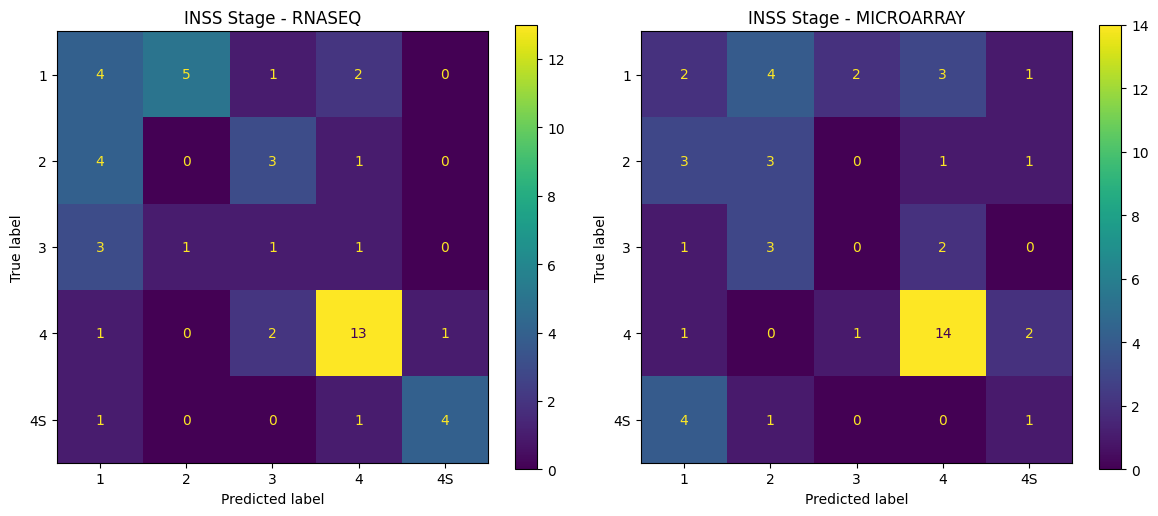

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_classes = 5
class_names = ['1', '2', '3', '4', '4S']  # original labels in encoded order

for idx, platform in enumerate(platforms):
    X_train, X_test, y_train, y_test = get_data(platform, 'inss_stage')

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            objective='multi:softprob',
            num_class=n_classes,
            eval_metric='mlogloss',
            verbosity=0,
            random_state=42
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=class_names,  # show original labels instead of 0,1,2,3,4
        ax=axes[idx]
    )
    axes[idx].set_title(f'INSS Stage - {platform.upper()}')

plt.tight_layout()
plt.show()

### Plot Performance metrics

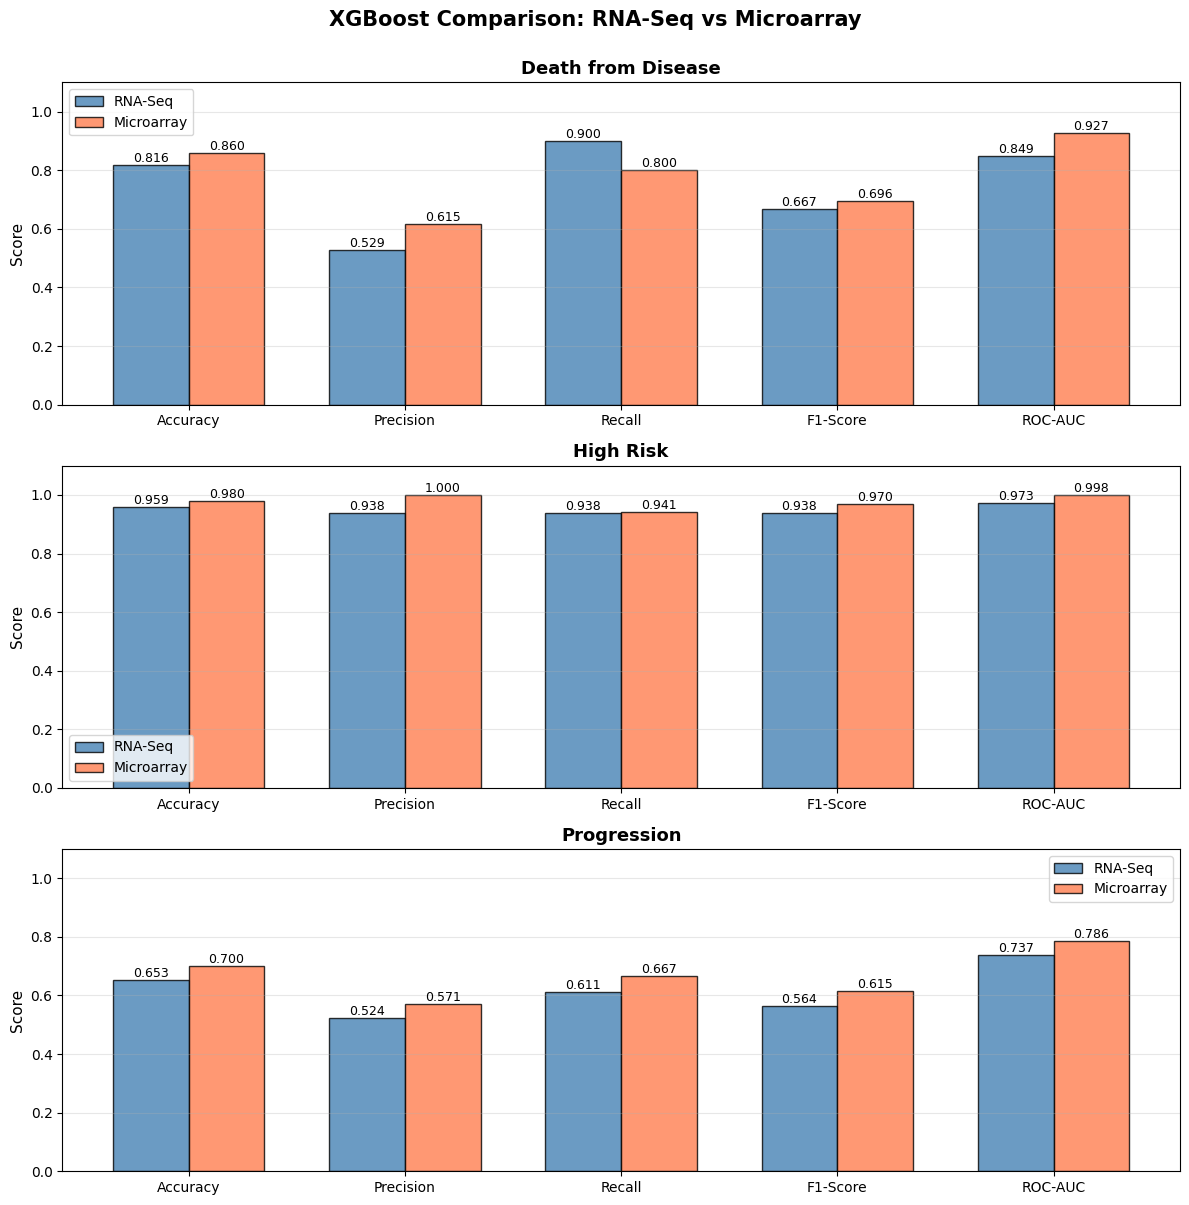

In [14]:
# Grouped Bar Chart - All Metrics
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(len(binary_outcomes), 1, figsize=(12, 12))

for idx, outcome in enumerate(binary_outcomes):  # changed from outcomes
    ax = axes[idx]

    outcome_data = results_df[results_df['Outcome'] == outcome.replace('_', ' ').title()]

    x = np.arange(len(metrics))
    width = 0.35

    rnaseq_values = outcome_data[outcome_data['Platform'] == 'RNASEQ'][metrics].values[0]
    microarray_values = outcome_data[outcome_data['Platform'] == 'MICROARRAY'][metrics].values[0]

    bars1 = ax.bar(x - width/2, rnaseq_values, width, label='RNA-Seq',
                   color='steelblue', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, microarray_values, width, label='Microarray',
                   color='coral', alpha=0.8, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost Comparison: RNA-Seq vs Microarray',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Interpretation

### Death from Disease
Microarray significantly outperforms RNA-Seq
(AUC: 0.928 vs 0.849), the largest gap seen across all models for this outcome.
Both platforms maintain high recall (~0.80-0.90), prioritising sensitivity for
mortality prediction. XGBoost's microarray performance is the best across all models
for this outcome.

### High Risk
Consistently strong across both platforms (AUC: RNASEQ=0.973, MICROARRAY=0.998),
with microarray achieving near-perfect discrimination. The balanced precision and
recall (~0.94) on both platforms suggests XGBoost captures the high risk
transcriptional signature robustly without over-predicting either class.

### Progression
XGBoost performs weakest for progression compared to LR and RF, particularly for
RNA-Seq (AUC: 0.737). This suggests XGBoost's boosting approach may overfit to
noise in the progression signal, which appears to be better captured by linear
(LR) or bagging-based (RF) approaches.

### INSS Stage
Performance is comparable to Random Forest (AUC: ~0.77), with similar difficulty
on intermediate stages. RNA-Seq marginally outperforms microarray (0.769 vs 0.767),
consistent with a modest platform difference for multiclass staging.

### Overall
XGBoost is the strongest model for microarray data, particularly for death from
disease and high risk prediction, but underperforms relative to LR and RF for
RNA-Seq progression which suggests no single model dominates across all
outcome and platform combinations.

In [15]:
# Save results for plotting notebook
results_df['Model'] = 'XGBoost'  # add model name
results_df.to_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_xg.csv', index=False)

## Train models on all outcomes with Hyperparameter Tuning (takes a while to run)

In [ ]:
outcomes = ['death_from_disease', 'high_risk', 'progression', 'inss_stage']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}
best_params = {}

print("=" * 70)
print("TRAINING XGBOOST MODELS WITH HYPERPARAMETER TUNING")
print("=" * 70)

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}
    best_params[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Detect multiclass
        n_classes = len(y_test.unique())
        is_multiclass = n_classes > 2
        average = 'weighted' if is_multiclass else 'binary'

        if not is_multiclass:
            scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

        # Base pipeline — no fixed hyperparameters except fixed settings
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(
                scale_pos_weight=scale_pos_weight if not is_multiclass else 1,
                objective='binary:logistic' if not is_multiclass else 'multi:softprob',
                num_class=n_classes if is_multiclass else None,
                random_state=42,
                eval_metric='logloss' if not is_multiclass else 'mlogloss',
                verbosity=0
            ))
        ])

        # Hyperparameter search space
        param_dist = {
            'model__n_estimators': randint(100, 400),
            'model__max_depth': [3, 4, 5, 6, 7],
            'model__learning_rate': uniform(0.01, 0.3),
            'model__subsample': uniform(0.6, 0.4),
            'model__colsample_bytree': uniform(0.3, 0.7),
            'model__min_child_weight': randint(1, 10),
            'model__gamma': uniform(0, 0.5)
        }

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=param_dist,
            n_iter=30,
            scoring='roc_auc_ovr_weighted' if is_multiclass else 'roc_auc',
            cv=5,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

        search.fit(X_train, y_train)

        best_params[outcome][platform] = search.best_params_
        print(f"  Best CV score: {search.best_score_:.4f}")
        print(f"  Best params: {search.best_params_}")

        # Predict using best model
        y_pred = search.predict(X_test)
        y_proba = search.predict_proba(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0, average=average)
        recall = recall_score(y_test, y_pred, zero_division=0, average=average)
        f1 = f1_score(y_test, y_pred, zero_division=0, average=average)

        if is_multiclass:
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        else:
            y_proba = y_proba[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)

        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        if not is_multiclass:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data[outcome][platform] = {
                'fpr': fpr,
                'tpr': tpr,
                'auc': roc_auc,
                'y_val': y_test,
                'y_proba': y_proba
            }

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

# Print best parameters
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS PER OUTCOME/PLATFORM")
print("=" * 70)
for outcome, platform_params in best_params.items():
    for platform, params in platform_params.items():
        print(f"\n{outcome.upper()} - {platform.upper()}:")
        for k, v in params.items():
            print(f"  {k}: {v}")

TRAINING XGBOOST MODELS WITH HYPERPARAMETER TUNING

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}
  Best CV score: 0.9080
  Best params: {'model__colsample_bytree': np.float64(0.57660516520127), 'model__gamma': np.float64(0.4633294328968971), 'model__learning_rate': np.float64(0.22818159875692626), 'model__max_depth': 6, 'model__min_child_weight': 9, 'model__n_estimators': 289, 'model__subsample': np.float64(0.7301321323053057)}
  Accuracy:  0.7755
  Precision: 0.4737
  Recall:    0.9000
  F1-Score:  0.6207
  ROC-AUC:   0.8744

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
